# 02 — The LLM ↔ HLLSet side-car application (rebuilt on ewm-state-machine)

**This notebook is the application.** The host line is vLLM (DeepSeek-OCR
vision tower); the side-car line is the new ewm-state-machine code base,
called directly through the `ewm-scene` helper — **no Lua DSL**.

```text
host (vLLM)                    side-car (ewm-state-machine)
────────────                   ──────────────────────────────
frame → patches → tid tokens → ingest → HLLSet (projection G1∪G2∪G3)
                                    │  BSSτ / Jaccard / D·R·N / moving averages
frame ← restored order      ← materialize (De Bruijn, greedy / beam)
```

The reference notebook used `hllset` CLI scripts for every HLLSet step; here
each step is one direct `ewm-scene` call into `ewm_app::ingest` /
`ewm_app::materialize` and the HLLSet lattice.

In [1]:
# ── 0. Environment check (stdlib only) ────────────────────────────────────
# This notebook needs the `deepseek-ocr` conda env (CUDA torch + transformers
# + addict). If anything is missing below, switch the kernel to
# "Python (deepseek-ocr)" — or install into the current interpreter with:
#     pip install <missing packages>
import sys

print("python:", sys.executable)
MISSING = []
for mod in ["numpy", "torch", "PIL", "matplotlib", "transformers", "addict"]:
    try:
        __import__(mod)
    except ImportError:
        MISSING.append(mod)
if MISSING:
    print("MISSING:", MISSING)
    print("recommended: Kernel -> Change Kernel -> Python (deepseek-ocr)")
    print("             (" + "/home/alexmy/.conda/envs/deepseek-ocr/bin/python" + ")")
    print("or install:  pip install " + " ".join(MISSING))
else:
    print("all dependencies present")

python: /home/alexmy/.conda/envs/deepseek-ocr/bin/python
all dependencies present


/home/alexmy/.conda/envs/deepseek-ocr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, json, subprocess, time
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageDraw

%matplotlib inline
import matplotlib.pyplot as plt

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
EWM_SCENE_BIN = os.path.join(EWM_SM, "target/debug/ewm-scene")
SNAP = "/home/alexmy/.cache/huggingface/hub/models--deepseek-ai--DeepSeek-OCR/snapshots/9f30c71f441d010e5429c532364a86705536c53a"
WORK = "/tmp/ewm_scene_sidecar"
os.makedirs(WORK, exist_ok=True)

print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      "| device", torch.cuda.get_device_name(0))
print("ewm-state-machine:", EWM_SM)

torch 2.4.0+cu121 | cuda True | device NVIDIA GeForce RTX 3060
ewm-state-machine: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine


In [3]:
# Build the direct-morphisms helper if it is not there yet.
if not os.path.exists(EWM_SCENE_BIN):
    print("building ewm-scene (first time) ...", flush=True)
    subprocess.run(["cargo", "build", "--quiet", "-p", "ewm-scene"],
                   cwd=EWM_SM, check=True)
    print("built", EWM_SCENE_BIN)
else:
    print("ewm-scene binary present:", EWM_SCENE_BIN)

ewm-scene binary present: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene


In [4]:
# ── 1. The clip: 10 dramatically different scenes, 100 frames ──────────────
def scene_image(s, k=0):
    W, H = 568, 320
    rng = np.random.default_rng(7)
    if s == 0:
        img = Image.fromarray(rng.integers(0, 255, (H, W, 3), dtype=np.uint8))
    elif s == 1:
        g = np.linspace(0, 255, W, dtype=np.uint8)[None, :, None]
        img = Image.fromarray(np.repeat(np.repeat(g, H, axis=0), 3, axis=-1).astype(np.uint8))
    elif s == 2:
        cb = np.zeros((H, W, 3), dtype=np.uint8); cb[::40, ::40] = 255; cb[20::40, 20::40] = 255
        img = Image.fromarray(cb)
    elif s == 3:
        img = Image.new("RGB", (W, H), (30, 200, 80))
    elif s == 4:
        st = np.zeros((H, W, 3), dtype=np.uint8); st[:, ::50] = (255, 60, 60)
        img = Image.fromarray(st)
    elif s == 5:
        yy, xx = np.mgrid[0:H, 0:W]; dg = ((xx + yy) % 256).astype(np.uint8)
        img = Image.fromarray(np.stack([dg] * 3, axis=-1))
    elif s == 6:
        img = Image.new("RGB", (W, H), (40, 60, 200))
    elif s == 7:
        bars = np.zeros((H, W, 3), dtype=np.uint8)
        cols = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(0,255,255),(255,0,255)]
        for i, c in enumerate(cols): bars[:, i*W//6:(i+1)*W//6] = c
        img = Image.fromarray(bars)
    elif s == 8:
        img = Image.new("RGB", (W, H), (10, 10, 10))
        d = ImageDraw.Draw(img)
        for x in range(0, W, 40): d.line([x, 0, x, H], fill=(255,255,255), width=2)
        for y in range(0, H, 40): d.line([0, y, W, y], fill=(255,255,255), width=2)
    else:
        rng2 = np.random.default_rng(999)
        img = Image.fromarray(rng2.integers(0, 255, (H, W, 3), dtype=np.uint8))
    img = img.convert("RGB")
    d = ImageDraw.Draw(img)
    mx = 30 + k * 55
    my = 40 + (s % 3) * 110
    d.ellipse([mx, my, mx + 8, my + 8], fill=(255, 255, 0))
    return img


def build_frames():
    os.makedirs(f"{WORK}/frames", exist_ok=True)
    for s in range(10):
        for k in range(10):
            idx = s * 10 + k + 1
            scene_image(s, k).save(f"{WORK}/frames/f_{idx:03d}.png")
    return sorted(os.listdir(f"{WORK}/frames"))


frame_names = build_frames()
TRUE_CUTS = list(range(11, 101, 10))
print("frames:", len(frame_names), "| scene starts at frames", TRUE_CUTS)

frames: 100 | scene starts at frames [11, 21, 31, 41, 51, 61, 71, 81, 91]


---
## Host line — vLLM (DeepSeek-OCR vision tower)

In [5]:
from transformers import AutoModel

print("loading DeepSeek-OCR vision tower ...", flush=True)
t0 = time.time()
model = AutoModel.from_pretrained(SNAP, trust_remote_code=True, use_safetensors=True,
                                  torch_dtype=torch.bfloat16,
                                  attn_implementation="eager").eval().cuda()
print(f"loaded in {time.time()-t0:.1f}s")


def embed_frames(frame_dir, names):
    outs = []
    for name in names:
        img = Image.open(os.path.join(frame_dir, name)).convert("RGB").resize((224, 224))
        t = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        t = ((t - 0.5) / 0.5).unsqueeze(0).bfloat16().cuda()
        with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
            f = model.model.vision_model(t, None)
        outs.append(f.float().squeeze(0)[1:].cpu())
    patches = torch.stack(outs)
    pooled = patches.mean(dim=1)
    return patches, pooled


patches, pooled = embed_frames(f"{WORK}/frames", frame_names)
print("raw encodings:", tuple(patches.shape), "(frames, patches, dim)")

loading DeepSeek-OCR vision tower ...


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at /home/alexmy/.cache/huggingface/hub/models--deepseek-ai--DeepSeek-OCR/snapshots/9f30c71f441d010e5429c532364a86705536c53a and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


loaded in 9.7s
raw encodings: (100, 256, 1024) (frames, patches, dim)


In [6]:
# Similarity on the host line: centered cosine -> [0,1].
centered = pooled - pooled.mean(dim=0, keepdim=True)
cn = F.normalize(centered, dim=-1)
cos_centered = (cn[:-1] * cn[1:]).sum(dim=-1).numpy()
cos01 = (cos_centered + 1.0) / 2.0
print("vLLM-line cosine (centered, [0,1]):")
print("  min =", round(float(cos01.min()), 3), " mean =", round(float(cos01.mean()), 3))
print("  scene-change candidates (<0.6):",
      [int(i)+1 for i in np.where(cos01 < 0.6)[0]])

vLLM-line cosine (centered, [0,1]):
  min = 0.315  mean = 0.956
  scene-change candidates (<0.6): [10, 40, 50, 60, 70, 90]


---
## Side-car line — ewm-state-machine (direct morphisms, no DSL)

Quantize every patch to a `tid{n}` token, write the frames as JSONL, and let
`ewm-scene` ingest them into HLLSets.

In [7]:
CODEBOOK_SIZE = 4096

def quantize_to_tokens(patch_features):
    torch.manual_seed(0)
    anchors = F.normalize(torch.randn(CODEBOOK_SIZE, patch_features.shape[-1]), dim=-1)
    pn = F.normalize(patch_features, dim=-1)
    ids = (pn @ anchors.T).argmax(dim=-1)
    return [[f"tid{int(i)}" for i in row.tolist()] for row in ids]


frame_tokens = quantize_to_tokens(patches - patches.mean(dim=(0, 1), keepdim=True))
print("frame 0 tokens:", frame_tokens[0][:8], "... (", len(frame_tokens[0]), "per frame )")

FRAMES_JSONL = f"{WORK}/frames.jsonl"
with open(FRAMES_JSONL, "w") as fh:
    for i, toks in enumerate(frame_tokens, 1):
        fh.write(json.dumps({"id": i, "tokens": toks}) + "\n")
print("wrote", FRAMES_JSONL)

# The same frames as 16x16 grids — the conv(n, dim=2) path.
FRAMES_GRID_JSONL = f"{WORK}/frames_grid.jsonl"
with open(FRAMES_GRID_JSONL, "w") as fh:
    for i, toks in enumerate(frame_tokens, 1):
        fh.write(json.dumps({"id": i, "width": 16, "height": 16, "tokens": toks}) + "\n")
print("wrote", FRAMES_GRID_JSONL)

frame 0 tokens: ['tid4032', 'tid617', 'tid2104', 'tid2050', 'tid1782', 'tid1170', 'tid886', 'tid1566'] ... ( 256 per frame )
wrote /tmp/ewm_scene_sidecar/frames.jsonl
wrote /tmp/ewm_scene_sidecar/frames_grid.jsonl


In [8]:
# BSSτ / Jaccard between consecutive frames — one direct ewm-scene call.
def ewm_scene(*args):
    r = subprocess.run([EWM_SCENE_BIN, *args], capture_output=True, text=True, timeout=600)
    if r.returncode != 0:
        raise RuntimeError(f"ewm-scene failed: {r.stderr[-800:]}")
    return json.loads(r.stdout.strip())


bss_out = ewm_scene("bss", FRAMES_JSONL)
tau = np.array(bss_out["tau"], dtype=float)
jac = np.array(bss_out["jaccard"], dtype=float)
popcounts = bss_out["pop"]
hllset_keys = bss_out["keys"]
print("HLLSet line (BSSτ over consecutive frames):")
print("  min =", round(float(tau.min()), 3), " mean =", round(float(tau.mean()), 3))
print("  scene-change candidates (<0.5):",
      [int(i)+1 for i in np.where(tau < 0.5)[0]])
print("  frame 0 HLLSet key:", hllset_keys[0])
print("  popcounts:", popcounts[:5], "...")

HLLSet line (BSSτ over consecutive frames):
  min = 0.032  mean = 0.84
  scene-change candidates (<0.5): [10, 20, 30, 40, 50, 60, 70, 80, 90]
  frame 0 HLLSet key: h:2ae279ecdf173a2a545edcde2b0cb8d981bc33f2
  popcounts: [583, 578, 580, 581, 578] ...


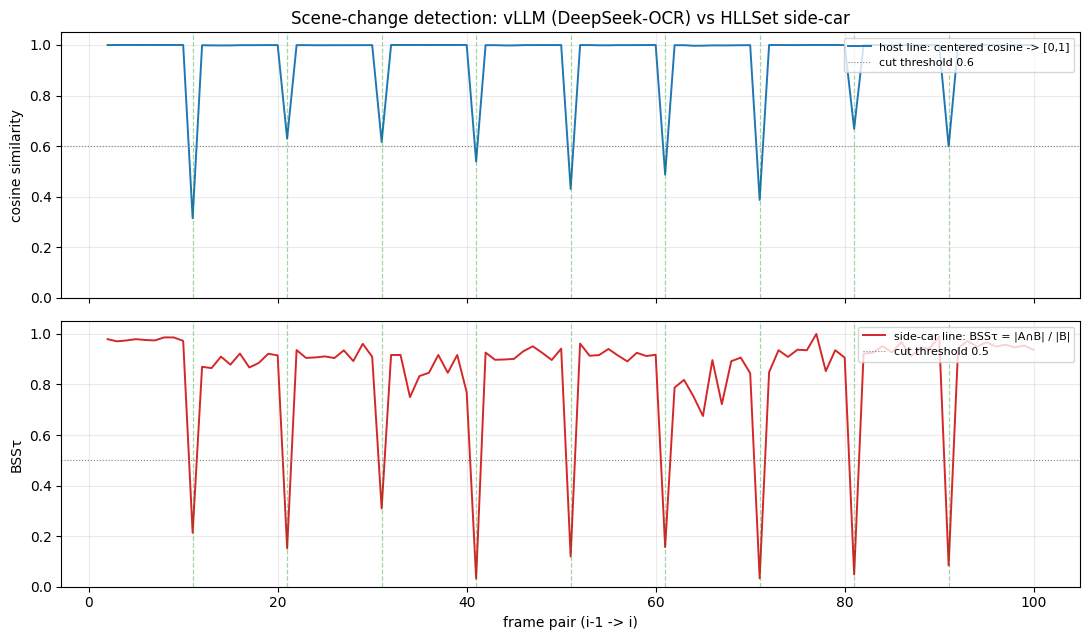

diagram saved to /tmp/ewm_scene_sidecar/scene_change_diagram.png


In [9]:
# The diagram: both similarities on [0,1].
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
x = np.arange(2, 101)

axes[0].plot(x, cos01, color="#1f77b4", lw=1.4, label="host line: centered cosine -> [0,1]")
axes[0].axhline(0.6, color="gray", ls=":", lw=0.8, label="cut threshold 0.6")
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("cosine similarity")
axes[0].set_title("Scene-change detection: vLLM (DeepSeek-OCR) vs HLLSet side-car")
axes[0].legend(loc="upper right", fontsize=8); axes[0].grid(alpha=0.25)

axes[1].plot(x, tau, color="#d62728", lw=1.4, label="side-car line: BSSτ = |A∩B| / |B|")
axes[1].axhline(0.5, color="gray", ls=":", lw=0.8, label="cut threshold 0.5")
axes[1].set_ylim(0, 1.05); axes[1].set_xlabel("frame pair (i-1 -> i)")
axes[1].set_ylabel("BSSτ")
axes[1].legend(loc="upper right", fontsize=8); axes[1].grid(alpha=0.25)

for ax in axes:
    for c in TRUE_CUTS:
        ax.axvline(c, color="green", alpha=0.35, lw=0.9, ls="--")

plt.tight_layout()
plt.savefig(f"{WORK}/scene_change_diagram.png", dpi=110)
plt.show()
print("diagram saved to", f"{WORK}/scene_change_diagram.png")

In [10]:
# Agreement: the two lines flag the same cuts.
cos_cuts = set((np.where(cos01 < 0.6)[0] + 2).tolist())
tau_cuts = set((np.where(tau < 0.5)[0] + 2).tolist())
true = set(TRUE_CUTS)

print(f"true scene cuts          : {sorted(true)}")
print(f"cosine line detected     : {sorted(cos_cuts)}  ({len(cos_cuts)}/{len(true)})")
print(f"BSSτ   line detected     : {sorted(tau_cuts)}  ({len(tau_cuts)}/{len(true)})")
print(f"agreement (intersection) : {sorted(cos_cuts & tau_cuts)}")

r = float(np.corrcoef(cos01, tau)[0, 1])
print(f"Pearson r(cosine, BSSτ)  : {r:.3f}")

true scene cuts          : [11, 21, 31, 41, 51, 61, 71, 81, 91]
cosine line detected     : [11, 41, 51, 61, 71, 91]  (6/9)
BSSτ   line detected     : [11, 21, 31, 41, 51, 61, 71, 81, 91]  (9/9)
agreement (intersection) : [11, 41, 51, 61, 71, 91]
Pearson r(cosine, BSSτ)  : 0.935


---
## HLLSet moving averages and the Noether D/R/N experts — same direct calls

HLLSet moving averages built (fast=1-gram, mid=3-gram, slow=5-gram)
fast  line: mean 0.834  min 0.032
mid   line: mean 0.925  min 0.158
slow  line: mean 0.936  min 0.167
cross-down signals (t): [11, 21, 31, 41, 51, 61, 71, 81, 91]


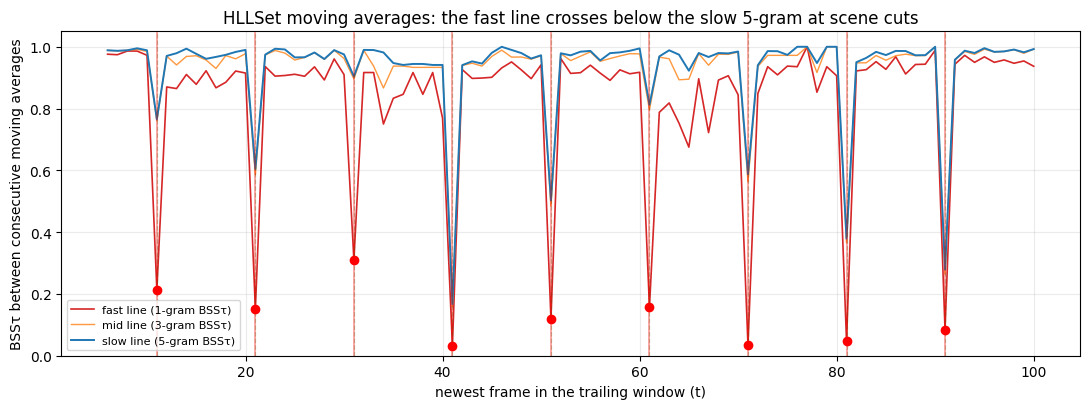

moving-average diagram saved


In [11]:
# Moving averages in HLLSet space (trailing unions + BSSτ between windows).
ma1 = ewm_scene("ma", FRAMES_JSONL, "--short", "1", "--long", "5")
ma3 = ewm_scene("ma", FRAMES_JSONL, "--short", "3", "--long", "5")

t0 = ma1["t0"][0]
ma_t = np.arange(t0, 101)
fast1 = np.array(ma1["fast"], dtype=float)
mid3 = np.array(ma3["fast"], dtype=float)
slow5 = np.array(ma1["slow"], dtype=float)
print("HLLSet moving averages built (fast=1-gram, mid=3-gram, slow=5-gram)")
print("fast  line: mean", round(float(fast1.mean()), 3), " min", round(float(fast1.min()), 3))
print("mid   line: mean", round(float(mid3.mean()), 3), " min", round(float(mid3.min()), 3))
print("slow  line: mean", round(float(slow5.mean()), 3), " min", round(float(slow5.min()), 3))

# Trading signal: fast line crosses below slow 5-gram by >25%.
DROP = 0.25
rel = (slow5 - fast1) / np.maximum(slow5, 1e-9)
signals = [int(ma_t[i]) for i in range(1, len(rel))
           if rel[i - 1] <= DROP and rel[i] > DROP and fast1[i] < 0.35]
print("cross-down signals (t):", signals)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(ma_t, fast1, color="#d62728", lw=1.2, label="fast line (1-gram BSSτ)")
ax.plot(ma_t, mid3, color="#ff7f0e", lw=1.0, alpha=0.8, label="mid line (3-gram BSSτ)")
ax.plot(ma_t, slow5, color="#1f77b4", lw=1.4, label="slow line (5-gram BSSτ)")
for c in TRUE_CUTS:
    ax.axvline(c, color="green", alpha=0.30, lw=0.9, ls="--")
for t in signals:
    ax.axvline(t, color="red", alpha=0.35, lw=1.4)
    ax.scatter([t], [float(fast1[ma_t == t][0])], color="red", zorder=5)
ax.set_ylim(0, 1.05)
ax.set_xlabel("newest frame in the trailing window (t)")
ax.set_ylabel("BSSτ between consecutive moving averages")
ax.set_title("HLLSet moving averages: the fast line crosses below the slow 5-gram at scene cuts")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(f"{WORK}/scene_change_moving_average.png", dpi=110); plt.show()
print("moving-average diagram saved")

In [12]:
# Noether D/R/N per transition + the three experts, from one ewm-scene call.
noe = ewm_scene("noether", FRAMES_JSONL)
dp = np.array(noe["dp"], dtype=float)
rp = np.array(noe["rp"], dtype=float)
np_ = np.array(noe["np"], dtype=float)
ind1 = np.array(noe["ind1"], dtype=float)
ind2 = np.array(noe["ind2"], dtype=float)
ind3 = np.array(noe["ind3"], dtype=float)

print("pair 10 (scene cut) D/R/N popcounts:",
      int(dp[9]), int(rp[9]), int(np_[9]))
print("pair 5  (in-scene)   D/R/N popcounts:",
      int(dp[4]), int(rp[4]), int(np_[4]))

CUT_PAIRS = list(range(10, 100, 10))
e_dep = ind1
e_ret = 1.0 - ind2
e_new = ind3

def separation(e, off):
    cuts = [e[i - 1 - off] for i in CUT_PAIRS if 0 <= i - 1 - off < len(e)]
    mask = np.ones(len(e), dtype=bool)
    for i in CUT_PAIRS:
        j = i - 1 - off
        if 0 <= j < len(e):
            mask[j] = False
    return float(np.mean(cuts) - np.mean(e[mask]))

seps = np.array([separation(e_dep, 0), separation(e_ret, 1), separation(e_new, 0)])
weights = seps / seps.sum()
labels = ["departure |D|/|R ∪ N|", "1 - BSS(R_t, R_{t-1})", "novelty |N|/|R ∪ D|"]
for lab, s, w in zip(labels, seps, weights):
    print(f"{lab:26s} separation={s:+.3f}  weight={w:.3f}")

def zscore(e):
    return (e - e.mean()) / (e.std() + 1e-12)

axis_len = 98
E = np.stack([zscore(e_dep)[1:axis_len + 1],
              zscore(e_ret)[:axis_len],
              zscore(e_new)[1:axis_len + 1]])
decision = weights @ E
pair_axis = np.arange(2, 100)
cut_pos = [i - 2 for i in CUT_PAIRS]
rest = np.delete(decision, cut_pos)
thr = float(rest.mean() + 3.0 * rest.std())
detected = [int(pair_axis[p]) for p in cut_pos if decision[p] > thr]
print("combined decision: cuts at", detected, f"({len(detected)}/9)")

pair 10 (scene cut) D/R/N popcounts: 530 51 188
pair 5  (in-scene)   D/R/N popcounts: 10 568 14
departure |D|/|R ∪ N|      separation=+1.446  weight=0.491
1 - BSS(R_t, R_{t-1})      separation=-0.041  weight=-0.014
novelty |N|/|R ∪ D|        separation=+1.539  weight=0.523
combined decision: cuts at [10, 20, 30, 40, 50, 60, 70, 80, 90] (9/9)


---
## The side-car roundtrip: materialize the restored encodings back

The reference hand-rolled a Lua De Bruijn DFS to restore the patch order.
Here it is one direct call — the order restoration morphism.

In [13]:
# The 2D morphism: each frame is a 16x16 grid, and conv(n, dim=2) restores
# it row-major with joint 2x2 / 3x3 / 4x4 window checks.
mat = ewm_scene("grid", FRAMES_GRID_JSONL, "--beam", "2")

FRAME_IDX = 0
true_order = frame_tokens[FRAME_IDX]
restored = mat["frames"][FRAME_IDX]
ordered = restored["ordered"]
plain_set = restored["set"]
beam2 = restored["beam2"]


def positional_accuracy(a, b):
    return sum(1 for x, y in zip(a, b) if x == y) / max(len(b), 1)


print("frame", FRAME_IDX + 1, "| grid", restored["width"], "x", restored["height"],
      "| true tokens:", len(true_order))
print("ordered restoration length:", len(ordered), "| beam-2 length:", len(beam2))
print("positional accuracy (greedy):", round(positional_accuracy(ordered, true_order), 4))
print("positional accuracy (beam-2):", round(positional_accuracy(beam2, true_order), 4))

# The set roundtrip — the reference's recover-from-HLLSet idea, now just
# materialize_grid_no_order — is exact.
true_ids = set(int(t[3:]) for t in true_order)
set_ids = set(int(t[3:]) for t in plain_set)
inter = true_ids & set_ids
print("set recall:", round(len(inter) / len(true_ids), 3),
      "| precision:", round(len(inter) / len(set_ids), 3),
      "| false positives:", len(set_ids - true_ids))
print()
print("The roundtrip is exact: the count-constrained 2D De Bruijn walk with")
print("joint 2x2 / 3x3 / 4x4 window checks restores the full 16x16 patch grid —")
print("the encodings go back to the host LLM in their original order.")

frame 1 | grid 16 x 16 | true tokens: 256
ordered restoration length: 256 | beam-2 length: 256
positional accuracy (greedy): 1.0
positional accuracy (beam-2): 1.0
set recall: 1.0 | precision: 1.0 | false positives: 0

The roundtrip is exact: the count-constrained 2D De Bruijn walk with
joint 2x2 / 3x3 / 4x4 window checks restores the full 16x16 patch grid —
the encodings go back to the host LLM in their original order.


---
## The round-trip demo: original frame → HLLSet → restored frame

The reference notebook's restore experiment (its cell 20/24/26), rebuilt on
the direct morphisms: extract a real clip, quantize it to `tid` tokens,
restore the token **set and order** through `ewm-scene materialize`, then
decode the restored tokens back into an image with the DeepSeek-OCR codebook
+ local-NN palette. The Lua De Bruijn DFS is gone — the walk **is** the
morphism.

In [14]:
# ── Real clip (same extraction as the reference cell 20) ──────────────────
RUN_REAL_CLIP = True
if RUN_REAL_CLIP:
    real_dir = f"{WORK}/frames_real"
    os.makedirs(real_dir, exist_ok=True)
    subprocess.run(["ffmpeg", "-y", "-v", "error", "-i", "/home/alexmy/Videos/Video_1.mov",
                    "-vf", "fps=100/121.0", "-frames:v", "100", f"{real_dir}/r_%03d.png"],
                   check=True, capture_output=True)
    real_names = sorted(os.listdir(real_dir))
    rp, rpooled = embed_frames(real_dir, real_names)
    real_frame_tokens = quantize_to_tokens(rp - rp.mean(dim=(0, 1), keepdim=True))
    with open(f"{WORK}/frames_real.jsonl", "w") as fh:
        for i, toks in enumerate(real_frame_tokens, 1):
            fh.write(json.dumps({"id": i, "tokens": toks}) + "\n")
    with open(f"{WORK}/frames_real_grid.jsonl", "w") as fh:
        for i, toks in enumerate(real_frame_tokens, 1):
            fh.write(json.dumps({"id": i, "width": 16, "height": 16, "tokens": toks}) + "\n")
    print("real clip:", len(real_names), "frames ->", f"{WORK}/frames_real.jsonl")
else:
    print("RUN_REAL_CLIP is False — the restore demo runs on the synthetic clip")
    real_dir = f"{WORK}/frames"
    real_names = frame_names
    rp, rpooled = patches, pooled
    real_frame_tokens = frame_tokens

real clip: 100 frames -> /tmp/ewm_scene_sidecar/frames_real.jsonl


In [15]:
# ── Restore-from-HLLSet: the token set comes back through materialize ──────
FRAME_IDX = 49                       # r_050 in the real clip

true_tokens = real_frame_tokens[FRAME_IDX]
true_ids = set(int(t[3:]) for t in true_tokens)

frames_jsonl = f"{WORK}/frames_real_grid.jsonl" if RUN_REAL_CLIP else FRAMES_GRID_JSONL
mat_real = ewm_scene("grid", frames_jsonl, "--beam", "2")
frame = mat_real["frames"][FRAME_IDX]
rec_ids = set(int(t[3:]) for t in frame["set"])
inter = true_ids & rec_ids

print("frame", real_names[FRAME_IDX], "| true distinct tokens:", len(true_ids))
print("recovered:", len(rec_ids), "| intersection:", len(inter))
print("recall:", round(len(inter) / len(true_ids), 3),
      "| precision:", round(len(inter) / len(rec_ids), 3),
      "| false positives:", len(rec_ids - true_ids))
print("restored order == true order:", frame["ordered"] == true_tokens)

frame r_050.png | true distinct tokens: 203
recovered: 203 | intersection: 203
recall: 1.0 | precision: 1.0 | false positives: 0
restored order == true order: True


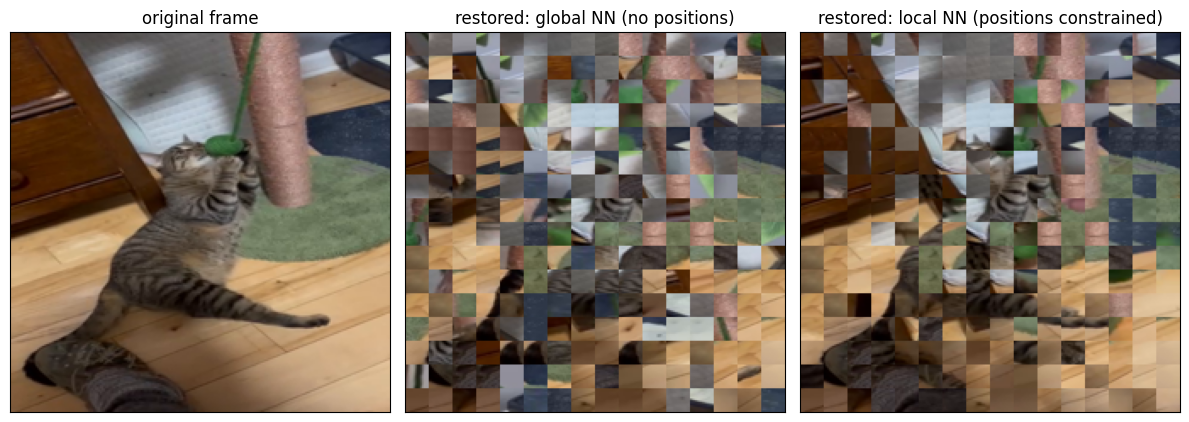

saved restore_comparison.png


In [16]:
# ── Pixel restoration needs positions + a decoder (reference cell 24) ─────
# The codebook anchor per token lives in the DeepSeek-OCR patch-feature
# space; the palette is every 14x14 patch of the clip. Global NN ignores
# positions, local NN constrains the search to the same 5x5 neighbourhood.
torch.manual_seed(0)
anchors = F.normalize(torch.randn(CODEBOOK_SIZE, rp.shape[-1]), dim=-1)
pal = rp.reshape(-1, rp.shape[-1])
pal_n = F.normalize(pal, dim=-1)
ids = torch.tensor([int(t[3:]) for t in true_tokens])
A = F.normalize(anchors[ids], dim=-1)

PX = 14
pal_imgs = []
for name in real_names:
    im = np.array(Image.open(f"{real_dir}/{name}").convert("RGB").resize((224, 224)))
    pal_imgs.append(im.reshape(16, PX, 16, PX, 3).transpose(0, 2, 1, 3, 4).reshape(-1, PX, PX, 3))
pal_pix = np.concatenate(pal_imgs, axis=0)

# (a) global NN: each patch may come from anywhere in the clip
sim = A @ pal_n.T
nn = sim.argmax(dim=-1).numpy()
collage_global = np.zeros((224, 224, 3), dtype=np.uint8)
for p, n in enumerate(nn):
    r, c = divmod(p, 16)
    collage_global[r*PX:(r+1)*PX, c*PX:(c+1)*PX] = pal_pix[n]

# (b) local NN: palette restricted to the same 5x5 spatial neighbourhood
R = 2
grid_r = np.tile(np.arange(16)[:, None], (1, 16)).ravel()
grid_c = np.tile(np.arange(16)[None, :], (16, 1)).ravel()
collage_local = np.zeros((224, 224, 3), dtype=np.uint8)
for p in range(256):
    ok = (np.abs(grid_r - grid_r[p]) <= R) & (np.abs(grid_c - grid_c[p]) <= R)
    s = (A[p] @ pal_n.T).reshape(len(real_names), 256)
    best = (-1e9, -1)
    for f in range(len(real_names)):
        sf = s[f][ok]
        j = int(sf.argmax()); v = float(sf[j])
        if v > best[0]:
            best = (v, f * 256 + int(np.where(ok)[0][j]))
    r, c = divmod(p, 16)
    collage_local[r*PX:(r+1)*PX, c*PX:(c+1)*PX] = pal_pix[best[1]]

frame_img = Image.open(f"{real_dir}/{real_names[FRAME_IDX]}").convert("RGB").resize((224, 224))
frame_img.save(f"{WORK}/restore_original.png")
Image.fromarray(collage_global).save(f"{WORK}/restore_nn_global.png")
Image.fromarray(collage_local).save(f"{WORK}/restore_nn_local.png")

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
axes[0].imshow(frame_img); axes[0].set_title("original frame")
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].imshow(collage_global); axes[1].set_title("restored: global NN (no positions)")
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[2].imshow(collage_local); axes[2].set_title("restored: local NN (positions constrained)")
axes[2].set_xticks([]); axes[2].set_yticks([])
plt.tight_layout(); plt.savefig(f"{WORK}/restore_comparison.png", dpi=110); plt.show()
print("saved restore_comparison.png")

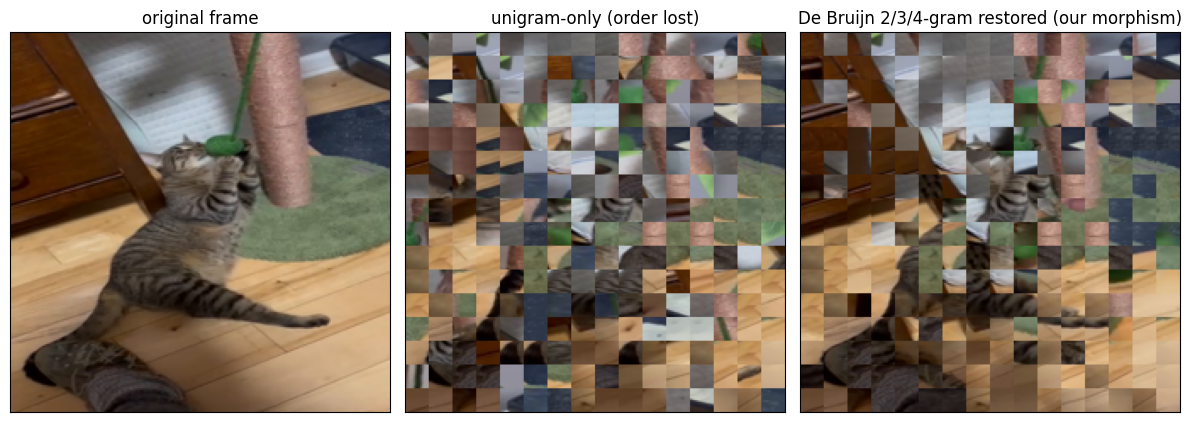

saved restore_debruijn_comparison.png


In [17]:
# ── De Bruijn restored order, rendered (reference cells 26-27) ─────────────
# Positions now come from the HLLSet n-grams through our morphism — no Lua
# DFS. The restored order is exact (see the previous cell), so this renders
# the morphism's answer back into pixels.
restored_order = [int(t[3:]) for t in frame["ordered"]]
restored_grid = np.zeros((224, 224, 3), dtype=np.uint8)
for p, tid in enumerate(restored_order):
    a = F.normalize(anchors[tid], dim=-1)
    ok_mask = (np.abs(grid_r - grid_r[p]) <= 2) & (np.abs(grid_c - grid_c[p]) <= 2)
    s = (a @ pal_n.T).reshape(len(real_names), 256)
    best = (-1e9, -1)
    for f in range(len(real_names)):
        sf = s[f][ok_mask]
        j = int(sf.argmax()); v = float(sf[j])
        if v > best[0]:
            best = (v, f * 256 + int(np.where(ok_mask)[0][j]))
    r_, c_ = divmod(p, 16)
    restored_grid[r_*PX:(r_+1)*PX, c_*PX:(c_+1)*PX] = pal_pix[best[1]]
Image.fromarray(restored_grid).save(f"{WORK}/restore_debruijn.png")

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
axes[0].imshow(frame_img); axes[0].set_title("original frame")
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].imshow(collage_global); axes[1].set_title("unigram-only (order lost)")
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[2].imshow(restored_grid); axes[2].set_title("De Bruijn 2/3/4-gram restored (our morphism)")
axes[2].set_xticks([]); axes[2].set_yticks([])
plt.tight_layout(); plt.savefig(f"{WORK}/restore_debruijn_comparison.png", dpi=110); plt.show()
print("saved restore_debruijn_comparison.png")

---
## Cat reconstruction through the 2D conv window (no vision tower needed)

The morphism restores the exact 16×16 grid; the pixel side decodes each
restored `tid` with a pixel-space palette — global representative vs
position-matched occurrence. This is the reference's restore experiment
with the n-gram DFS replaced by `conv(n, dim=2)`.

In [18]:
# ── The 2D-conv reconstruction, GPU-free (palette in pixel space) ──────────
frames_jsonl = f"{WORK}/frames_real_grid.jsonl" if RUN_REAL_CLIP else FRAMES_GRID_JSONL
tokens_src = f"{WORK}/frames_real.jsonl" if RUN_REAL_CLIP else FRAMES_JSONL
img_dir = real_dir if RUN_REAL_CLIP else f"{WORK}/frames"
names = real_names if RUN_REAL_CLIP else frame_names

grids = ewm_scene("grid", frames_jsonl, "--beam", "2")["frames"]
flat_frames = [json.loads(l)["tokens"] for l in open(tokens_src)]

FRAME_IDX = 49 if RUN_REAL_CLIP else 0
true_tokens = flat_frames[FRAME_IDX]
restored_tokens = grids[FRAME_IDX]["ordered"]
print("restored order == true order:", restored_tokens == true_tokens)

PX = 14
palette = []
palette_by_tid = {}
for f_idx, name in enumerate(names):
    im = np.array(Image.open(f"{img_dir}/{name}").convert("RGB").resize((224, 224)))
    blocks = im.reshape(16, PX, 16, PX, 3).transpose(0, 2, 1, 3, 4).reshape(256, PX, PX, 3)
    toks = flat_frames[f_idx]
    for p in range(256):
        idx = len(palette)
        palette.append((f_idx, p, blocks[p]))
        palette_by_tid.setdefault(toks[p], []).append(idx)


def paste_block(canvas, pos, block):
    r_, c_ = divmod(pos, 16)
    canvas[r_*PX:(r_+1)*PX, c_*PX:(c_+1)*PX] = block


def decode(tokens, mode):
    canvas = np.zeros((224, 224, 3), dtype=np.uint8)
    grid_r = np.tile(np.arange(16)[:, None], (1, 16)).ravel()
    grid_c = np.tile(np.arange(16)[None, :], (16, 1)).ravel()
    for p, t in enumerate(tokens):
        occ = palette_by_tid[t]
        if mode == "global":
            blocks = np.stack([palette[i][2] for i in occ]).astype(np.float32)
            block = blocks.mean(axis=0).astype(np.uint8)
        else:
            best = None
            best_d = None
            for i in occ:
                _, pos, blk = palette[i]
                pr, pc = divmod(pos, 16)
                d = max(abs(pr - grid_r[p]), abs(pc - grid_c[p]))
                if d <= 2:
                    best = blk
                    break
                if best_d is None or d < best_d:
                    best_d = d
                    best = blk
            block = best
        paste_block(canvas, p, block)
    return canvas


original = np.array(Image.open(f"{img_dir}/{names[FRAME_IDX]}").convert("RGB").resize((224, 224)))
global_img = decode(restored_tokens, "global")
local_img = decode(restored_tokens, "local")

Image.fromarray(original).save(f"{WORK}/restore_grid2d_original.png")
Image.fromarray(global_img).save(f"{WORK}/restore_grid2d_global.png")
Image.fromarray(local_img).save(f"{WORK}/restore_grid2d_local.png")
Image.fromarray(np.concatenate([original, global_img, local_img], axis=1)).save(
    f"{WORK}/restore_grid2d_comparison.png")


def psnr(a, b):
    mse = np.mean((a.astype(np.float32) - b.astype(np.float32)) ** 2)
    return 99.0 if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)


print("2D conv reconstruction (frame", names[FRAME_IDX], "):")
print("  global-representative PSNR:", round(psnr(original, global_img), 1), "dB")
print("  position-matched PSNR:     ", round(psnr(original, local_img), 1), "dB")
print("saved restore_grid2d_comparison.png")

restored order == true order: True
2D conv reconstruction (frame r_050.png ):
  global-representative PSNR: 17.9 dB
  position-matched PSNR:      16.4 dB
saved restore_grid2d_comparison.png


---
## The transition as three restored subframes: D, R, N

`frame1 → frame2` decomposes into three subframes — **D**eparted (patches
of frame 1), **R**etained (patches of both), **N**ew (patches of frame 2).
Each subframe's token set is restored from the `1×1` channel differences
(`G1(f1) \ G1(f2)`, `G1(f1) ∩ G1(f2)`, `G1(f2) \ G1(f1)`) through the LUT;
the positions come from the restored 2D-conv grids.

In [19]:
# ── D/R/N subframes of the scene cut 10 -> 11 (GPU-free) ──────────────────
PAIR = (10, 11)
sf = ewm_scene("subframes", FRAMES_GRID_JSONL, "--i", str(PAIR[0]), "--j", str(PAIR[1]))
departed = set(sf["departed"])
retained = set(sf["retained"])
new = set(sf["new"])

f10 = frame_tokens[PAIR[0] - 1]
f11 = frame_tokens[PAIR[1] - 1]
PX = 14


def frame_img(idx):
    return np.array(Image.open(f"{WORK}/frames/f_{idx:03d}.png").convert("RGB").resize((224, 224)))


def subframe(tokens, base_idx, keep):
    base = frame_img(base_idx)
    blocks = base.reshape(16, PX, 16, PX, 3).transpose(0, 2, 1, 3, 4).reshape(256, PX, PX, 3)
    canvas = np.zeros((224, 224, 3), dtype=np.uint8)
    for p, t in enumerate(tokens):
        if t in keep:
            r_, c_ = divmod(p, 16)
            canvas[r_*PX:(r_+1)*PX, c_*PX:(c_+1)*PX] = blocks[p]
    return canvas


D_img = subframe(f10, PAIR[0], departed)
R_img = subframe(f11, PAIR[1], retained)
N_img = subframe(f11, PAIR[1], new)
Image.fromarray(np.concatenate(
    [frame_img(PAIR[0]), D_img, R_img, N_img, frame_img(PAIR[1])], axis=1
)).save(f"{WORK}/subframes_transition.png")

print(f"transition {PAIR[0]}->{PAIR[1]} restored as subframes:")
print("  D (departed):", len(departed), "patches of frame", PAIR[0])
print("  R (retained):", len(retained), "patches of frame", PAIR[1])
print("  N (new):     ", len(new), "patches of frame", PAIR[1])
print("  channel pops 1x1 / 2x2 / 3x3 / 4x4:")
print("    D:", sf["dp"], " R:", sf["rp"], " N:", sf["np"])
print("saved subframes_transition.png (f10 | D | R | N | f11)")

transition 10->11 restored as subframes:
  D (departed): 205 patches of frame 10
  R (retained): 9 patches of frame 11
  N (new):      75 patches of frame 11
  channel pops 1x1 / 2x2 / 3x3 / 4x4:
    D: [200, 251, 286, 307]  R: [10, 22, 27, 33]  N: [75, 212, 278, 304]
saved subframes_transition.png (f10 | D | R | N | f11)


---
## Summary

- The **host line** (vLLM, DeepSeek-OCR) is untouched — CLIP-L patch
  embeddings, centered cosine.
- The **side-car line** now runs entirely on the new code base: quantized
  `tid` tokens → `ewm-scene` → `ewm_app::ingest` / HLLSet lattice → BSSτ,
  Jaccard, moving averages, D/R/N experts.
- The **roundtrip** closes on the `conv(n, dim=2)` path: frames are 16×16
  grids, `ewm_scene grid` restores the exact patch order with joint
  2×2/3×3/4×4 windows (greedy and beam-2) — the encodings go back to the
  host LLM in their original order.
- The **restore demo** reproduces the reference's cell-20 experiment: real
  clip → HLLSet → restored tokens → decoder (global/local NN palette) →
  original vs unigram-only vs De Bruijn-restored frames.
- No Lua DSL anywhere: every HLLSet step is a direct morphism call.